# Learn a reconstruction prior with a CNN

A CNN maps normalized backprojection and coverage to a field. Training examples are distinct whole fields, not pixels from the test image. This compact network uses a fixed sensor layout. Its compressed condition does not contain all measurement information.

**Objective:** actually train a supervised model, inspect its loss, and test on an independent seed.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


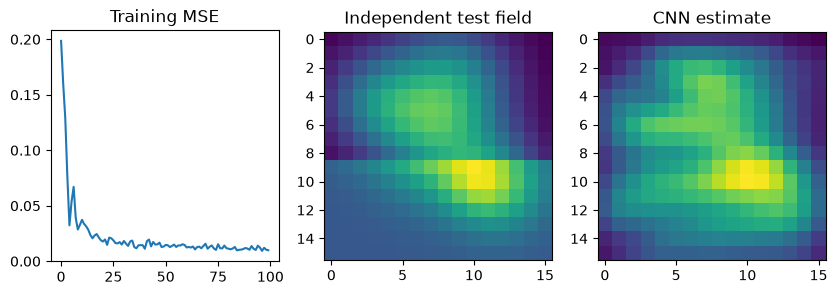

RMSE: 0.0943545968353032


In [2]:
from fieldlab.neural import train_cnn,predict_cnn
grid=Grid((16,16)); A,_=sensor_layout(grid,seed=6)
net,loss=train_cnn(grid,A,steps=100,count=96,seed=1000)
truth=simulate(grid,9000,kind='front'); y=observe(A,truth,.03,9001)
r=predict_cnn(net,grid,A,y)
fig,axes=plt.subplots(1,3,figsize=(10,3))
axes[0].plot(loss); axes[0].set_title('Training MSE')
axes[1].imshow(truth); axes[1].set_title('Independent test field')
axes[2].imshow(r.mean); axes[2].set_title('CNN estimate')
plt.show()
print('RMSE:',np.sqrt(np.mean((r.mean-truth)**2)))


**Exercise:** test a new sensor layout and report degradation. Train with several layouts as an extension. Compare against a GP using exactly the same observations. Add validation loss rather than treating training loss as generalization evidence.

See [theory notes](../docs/theory.md) for assumptions and equations.